# Project 14 - MNCs Salary Dataset

This dataset contains real-world salary information collected from multiple companies across different locations, job roles, and employment types. It is designed to help understand salary trends, pay distribution, and factors influencing compensation in the job market.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

In [2]:
data = pd.read_csv(r"D:\Python\Project 14\14. Salary_Dataset.csv")

In [3]:
data

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [53]:
data.describe()

,Rating,Salary,Salaries Reported
count,21014.000000,2.101400e+04,21014.000000
mean,3.913612,5.530529e+05,1.843818
std,0.524060,3.562545e+05,6.552598
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,8.000000e+05,1.000000
max,5.000000,1.550000e+06,361.000000


In [52]:
# if want to see more summary about the data
data.describe(include = 'all')

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,21014.000000,21013,21014,2.101400e+04,21014.000000,21014,21014,21014
unique,NaN,10838,981,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,266,2137,NaN,NaN,7471,18379,7245
mean,3.913612,NaN,NaN,5.530529e+05,1.843818,NaN,NaN,NaN
std,0.524060,NaN,NaN,3.562545e+05,6.552598,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,8.000000e+05,1.000000,NaN,NaN,NaN


In [50]:
data.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [51]:
data = data.drop_duplicates()

In [49]:
data

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# Checking the outlier & Removal

# - Visualize Salary Outlier

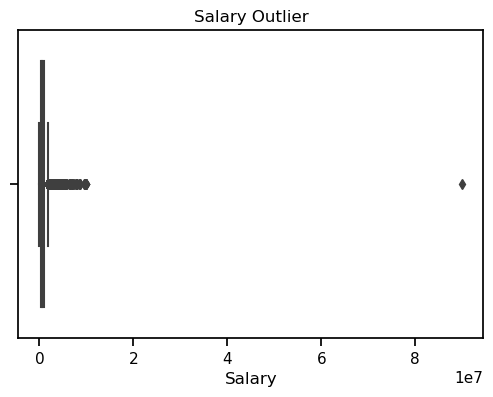

In [12]:
plt.figure(figsize = (6,4))
sns.boxplot(x = data['Salary'])

plt.title("Salary Outlier")
plt.show()

# - IQR (Interquartile Range) Method

In [15]:
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)
IQR = Q3 - Q1

In [16]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [18]:
data = data[(data['Salary'] >= lower_limit) & (data['Salary'] <= upper_limit)]
data

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# Univariate Analysis

# "Salary Distribution"

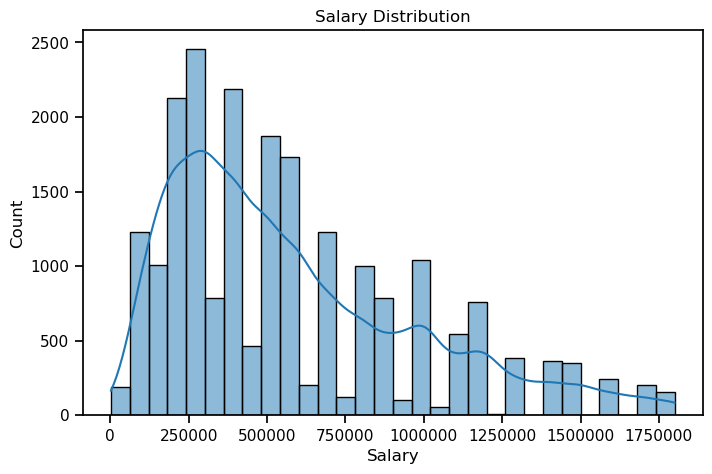

In [23]:
plt.figure(figsize = (8,5))
sns.histplot(data['Salary'], bins = 30, kde = True)

plt.ticklabel_format(style = 'plain', axis = 'x')

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

# 1. Which job roles have the highest average salary ?

In [45]:
data.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [46]:
data['Job Roles'].unique()

array(['Android', 'Backend', 'Database', 'Frontend', 'IOS', 'Java',
       'Mobile', 'SDE', 'Python', 'Web', 'Testing'], dtype=object)

In [47]:
avg_sal_jr = data.groupby('Job Roles')['Salary'].mean().sort_values(ascending = False)
avg_sal_jr

Job Roles
Database    702554.768392
SDE         648182.534714
IOS         593214.068241
Mobile      589857.819905
Backend     529104.564347
Frontend    501977.282203
Android     483352.318634
Java        475832.116985
Testing     464824.757895
Python      449531.694295
Web         392554.089069
Name: Salary, dtype: float64

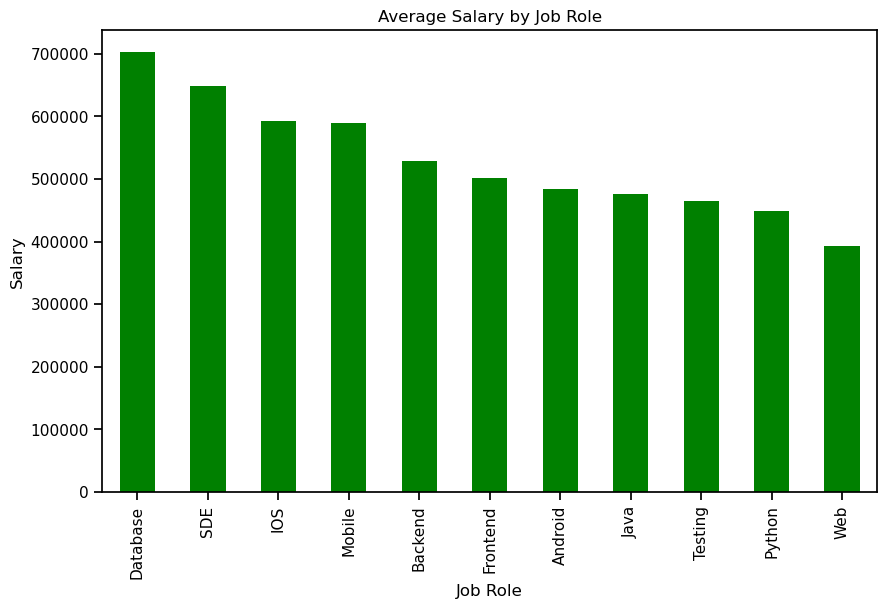

In [48]:
plt.figure(figsize = (10,6))

plt.grid()

avg_sal_jr.plot(x = avg_sal_jr.index, y = avg_sal_jr.values, kind = 'bar', color = 'green')

plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Salary")

plt.show()

# Checking the outlier again

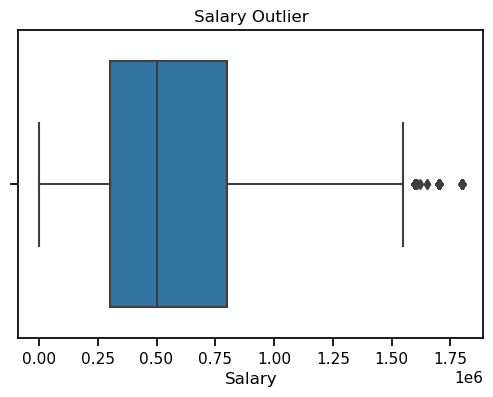

In [39]:
# Checking the outlier again
plt.figure(figsize = (6,4))
sns.boxplot(x = data['Salary'])

plt.title("Salary Outlier")
plt.show()

In [40]:
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)
IQR = Q3 - Q1

In [41]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [42]:
data = data[(data['Salary'] >= lower_limit) & (data['Salary'] <= upper_limit)]
data

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


# - look at the boxplot, there is no outlier now!

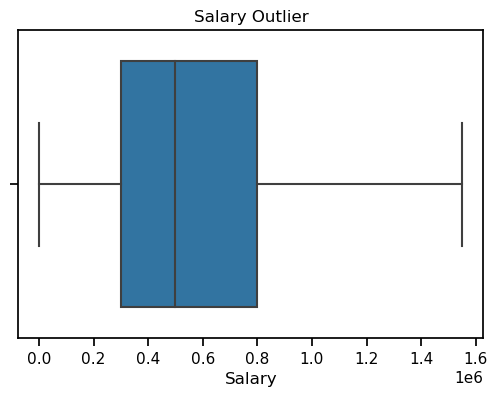

In [43]:
# Checking the outlier again
plt.figure(figsize = (6,4))
sns.boxplot(x = data['Salary'])

plt.title("Salary Outlier")
plt.show()

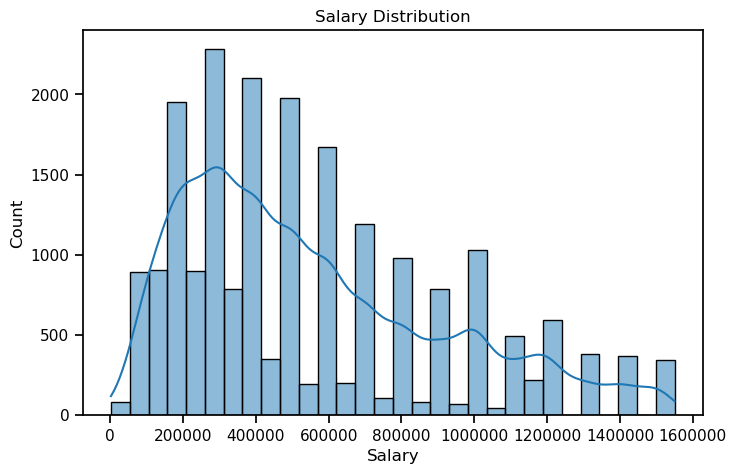

In [44]:
# checking salary distribution again
plt.figure(figsize = (8,5))
sns.histplot(data['Salary'], bins = 30, kde = True)

plt.ticklabel_format(style = 'plain', axis = 'x')

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

# 2. Which cities offer the highest average salary ?

In [55]:
data.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [59]:
city_salary = data.groupby('Location')['Salary'].mean().sort_values(ascending = False)
city_salary

Location
Mumbai            702195.874214
Bangalore         568223.271851
Jaipur            566153.846154
Pune              562387.138833
New Delhi         542717.057751
Hyderabad         538809.567450
Kolkata           532604.938272
Kerala            514965.735849
Chennai           505102.446337
Madhya Pradesh    497530.378378
Name: Salary, dtype: float64

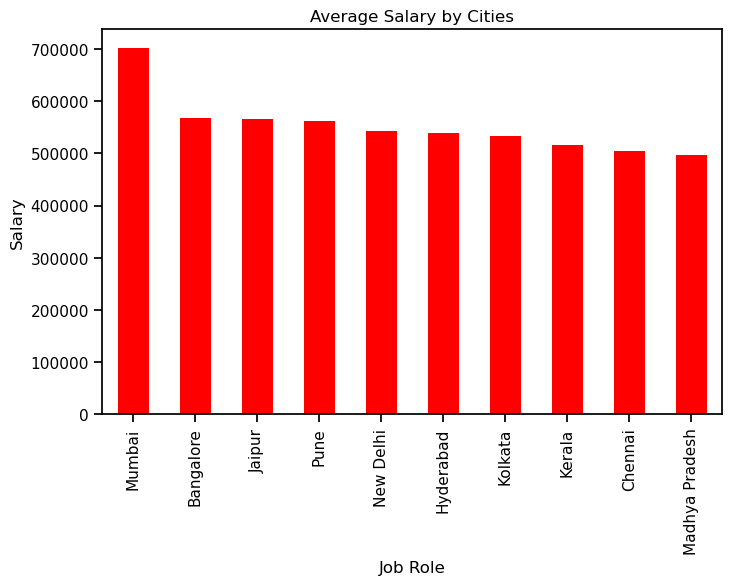

In [62]:
plt.figure(figsize = (8,5))

city_salary.plot(kind = 'bar', color = 'red')

plt.title("Average Salary by Cities")
plt.xlabel("Job Role")
plt.ylabel("Salary")

plt.show()

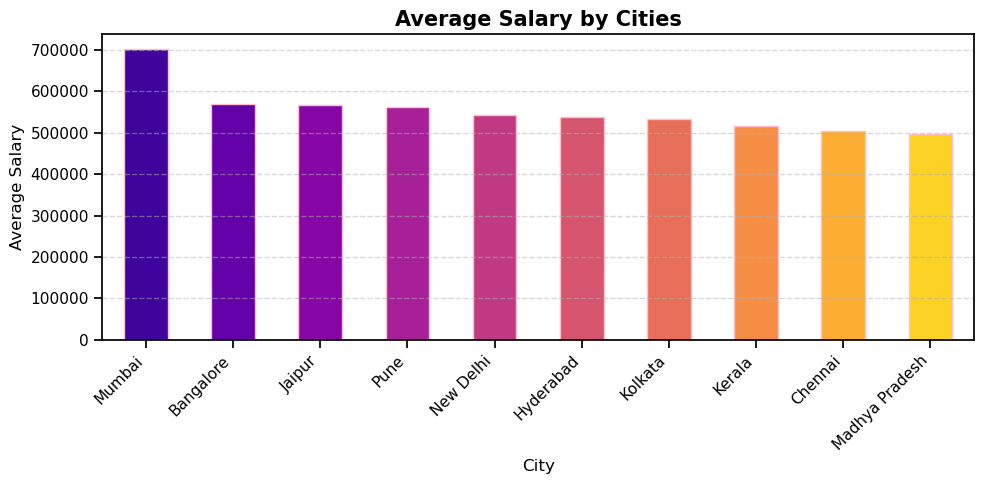

In [68]:
# another graph
plt.figure(figsize = (10,5))

colors = sns.color_palette("plasma", len(city_salary))

city_salary.plot(kind = 'bar', color = colors, edgecolor = 'pink')

plt.title("Average Salary by Cities", fontsize=15, fontweight = 'bold')
plt.xlabel("City")
plt.ylabel("Average Salary")

plt.xticks(rotation=45, ha="right")
plt.grid(axis = "y", linestyle = "--", alpha = 0.5)

plt.tight_layout()
plt.show()

# 4. Name those 5 companies located in New Delhi with rating of 5, offering highest and lowest salary ?

In [70]:
data.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [75]:
nd_sal_5 = data[(data['Location'] == 'New Delhi') & (data['Rating'] == 5.0)].sort_values(by = 'Salary', ascending = False)

In [76]:
nd_sal_5

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
6750,5.0,Hapramp,Front End Developer,1500000,1,New Delhi,Full Time,Frontend
1888,5.0,Trillbit,Android Developer,1500000,1,New Delhi,Full Time,Android
17488,5.0,The Art of Mike Mignola,Software Development Engineer,1500000,1,New Delhi,Full Time,SDE
8284,5.0,Silicon Valley Recycling,Senior IOS Developer,1400000,1,New Delhi,Full Time,IOS
17351,5.0,Parth Universal,Software Development Engineer,1300000,1,New Delhi,Full Time,SDE
...,...,...,...,...,...,...,...,...
1723,5.0,Neo Fitnes,Android Developer,100000,1,New Delhi,Full Time,Android
1969,5.0,WorkingNation,Android Developer - Intern,84000,1,New Delhi,Intern,Android
2334,5.0,Hopin (India),Android Developer - Intern,60000,1,New Delhi,Intern,Android
17524,5.0,Star Catalysts,Software Development Engineer - Intern,60000,1,New Delhi,Intern,SDE


In [77]:
list(nd_sal_5['Company Name'].head())

['Hapramp',
 'Trillbit',
 'The Art of Mike Mignola',
 'Silicon Valley Recycling',
 'Parth Universal']

In [78]:
list(nd_sal_5['Company Name'].tail())

['Neo Fitnes', 'WorkingNation', 'Hopin (India)', 'Star Catalysts', 'Atom 8']

# 5. Which Job Title has the highest number of salary reported ?

In [79]:
data.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [83]:
data['Job Title'].value_counts()

Job Title
Software Development Engineer          2137
Android Developer                      1983
Software Development Engineer (SDE)    1477
Front End Developer                    1360
Test Engineer                          1290
                                       ... 
Software Engineer III - IOS               1
Senior IOS Developer and Tech Lead        1
Associate Developer - IOS                 1
Senior Analyst (IOS/IPhone)               1
Associate Web Developer                   1
Name: count, Length: 981, dtype: int64

In [84]:
#another method
data.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending = False)

Job Title
Software Development Engineer                          2137
Android Developer                                      1983
Software Development Engineer (SDE)                    1477
Front End Developer                                    1360
Test Engineer                                          1290
                                                       ... 
Lead Software Development Engineer In Test Engineer       1
Lead Software Test Engineer                               1
Lead, IOS Team                                            1
Level II Mobile Technician                                1
Xamarin Mobile Developer                                  1
Name: Salaries Reported, Length: 981, dtype: int64

# 5. Top 5 companies offering the highest average salary, when at least 20 emoloyees have reported their salaries ?

In [85]:
data.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [88]:
filtered_df = data[data['Salaries Reported'] >= 20]
filtered_df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
8790,3.9,Tata Consultancy Services,Java Developer,200000,30,Chennai,Full Time,Java
8977,3.8,Cognizant Technology Solutions,Senior Java Developer,200000,35,Chennai,Full Time,Java
8978,3.9,Tata Consultancy Services,Senior Java Developer,300000,30,Chennai,Full Time,Java
8979,3.9,Tata Consultancy Services,Junior Java Developer,200000,30,Chennai,Full Time,Java
9688,3.9,Tata Consultancy Services,Java Developer,200000,43,Hyderabad,Full Time,Java
...,...,...,...,...,...,...,...,...
21762,3.8,CGI,Senior Test Engineer,400000,21,Bangalore,Full Time,Testing
21763,4.1,IBM,Test Automation Engineer,400000,21,Bangalore,Full Time,Testing
21764,3.7,SLK Group,Software Test Engineer,300000,20,Bangalore,Full Time,SDE
21765,4.3,Cisco Systems,Software Test Engineer,700000,20,Bangalore,Full Time,SDE


In [90]:
filtered_df.groupby('Company Name')['Salary'].mean().sort_values(ascending = False).head(10)

Company Name
Expedia Group     1.350000e+06
Nokia             1.200000e+06
Amadeus           1.200000e+06
Ola               1.000000e+06
Alcatel-Lucent    1.000000e+06
Lumen             9.000000e+05
Kony              9.000000e+05
Microsoft         7.845714e+05
Cisco Systems     7.000000e+05
McAfee            6.500000e+05
Name: Salary, dtype: float64

# 6. Is there a relationship between company rating and salary ?

In [92]:
data['Rating'].corr(data['Salary'])

0.02477162838343553

In [96]:
#another method to show correlation
data[['Rating', 'Salary', 'Salaries Reported']].corr()

,Rating,Salary,Salaries Reported
Rating,1.000000,0.024772,-0.013516
Salary,0.024772,1.000000,-0.021672
Salaries Reported,-0.013516,-0.021672,1.000000


<Axes: >

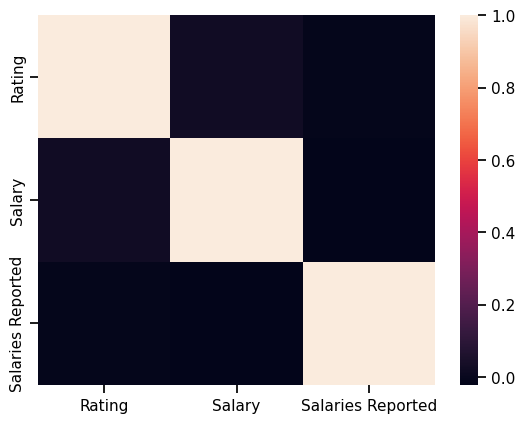

In [94]:
#showing correlation wit heatmap
sns.heatmap(data.corr(numeric_only = True))

D:\Anaconda1\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


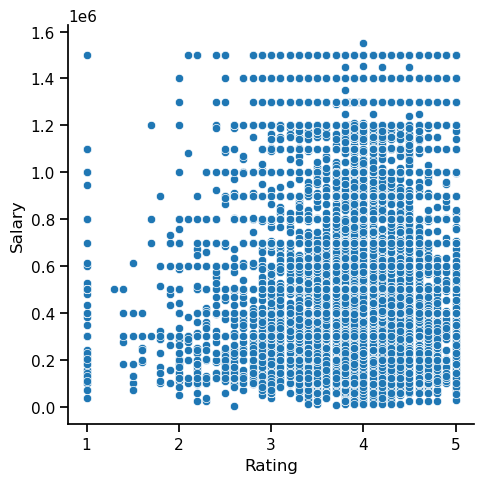

In [97]:
sns.relplot(x='Rating', y = 'Salary', data = data)
plt.show()

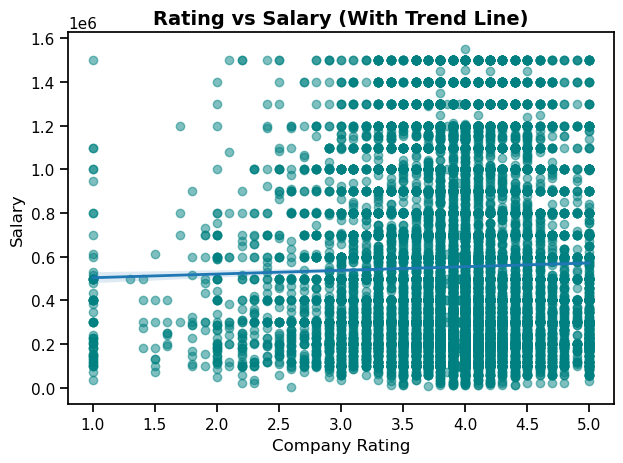

In [98]:
sns.regplot(x='Rating', y = 'Salary', data = data, scatter_kws = {"alpha":0.5, "color": "teal"}, line_kws = {"linewidth":2})

plt.title("Rating vs Salary (With Trend Line)", fontsize = 14, fontweight = "bold")
plt.xlabel("Company Rating")
plt.ylabel("Salary")
plt.tight_layout()

plt.show()

# 7. Does employment status affect salary ?

In [99]:
data.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [100]:
data['Employment Status'].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [101]:
data['Employment Status'].value_counts()

Employment Status
Full Time     18379
Intern         2089
Contractor      513
Trainee          33
Name: count, dtype: int64

In [102]:
data.groupby('Employment Status')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18379.0,579305.536101,358065.460032,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


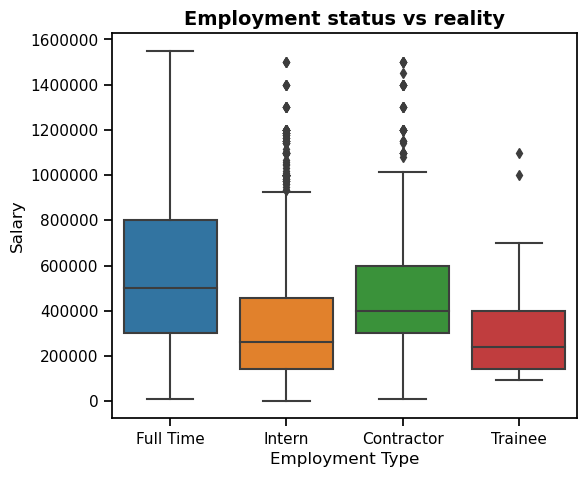

In [106]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Employment Status", y = "Salary", data = data)

plt.ticklabel_format(style = 'plain', axis = 'y')

plt.title("Employment status vs reality", fontsize = 14, fontweight = "bold")
plt.xlabel("Employment Type")
plt.ylabel("Salary")

plt.show()

# 8. Which job roles are most common ?

In [107]:
data.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [108]:
data['Job Roles'].value_counts()

Job Roles
SDE         7245
Android     2812
Frontend    2034
Java        1778
Testing     1710
IOS         1524
Backend     1049
Web          988
Python       929
Database     734
Mobile       211
Name: count, dtype: int64

In [109]:
top_roles = data['Job Roles'].value_counts().head(10)
top_roles

Job Roles
SDE         7245
Android     2812
Frontend    2034
Java        1778
Testing     1710
IOS         1524
Backend     1049
Web          988
Python       929
Database     734
Name: count, dtype: int64

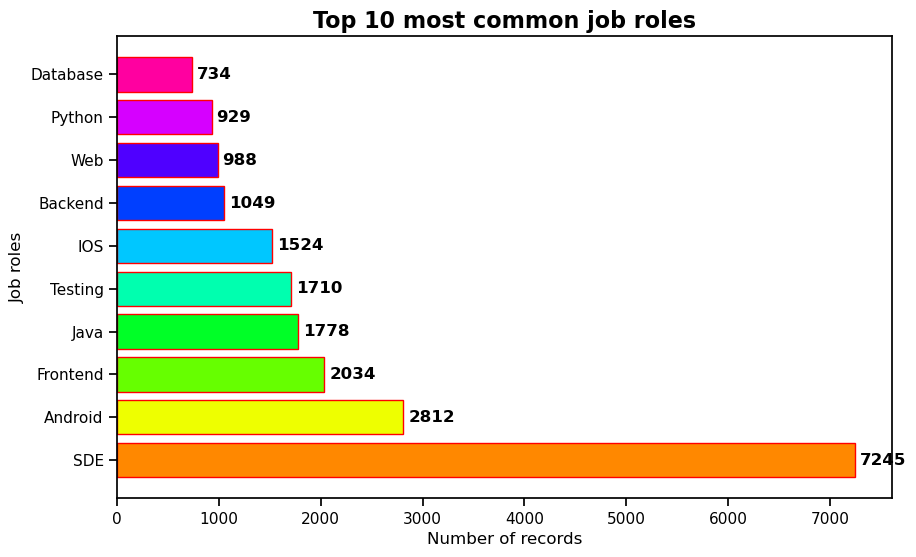

In [114]:
plt.figure(figsize = (10,6))

# use color gradient
colors = sns.color_palette("hsv", len(top_roles))

#horizontal bar chart
plt.barh(top_roles.index, top_roles.values, color = colors, edgecolor = 'red')

# Add value labels on bars
for i, v in enumerate(top_roles.values):
    plt.text(v + 50, i, str(v), va = 'center', fontweight = 'bold')
    
plt.title("Top 10 most common job roles", fontsize = 16, fontweight = "bold")
plt.xlabel("Number of records", fontsize = 12)
plt.ylabel("Job roles", fontsize = 12)

plt.show()

# 9. How does average salary changes as company rating increases ?

In [115]:
data.groupby('Rating')['Salary'].mean().reset_index()

,Rating,Salary
0,1.00,399971.500000
1,1.30,500000.000000
2,1.40,331200.000000
3,1.50,241000.000000
4,1.60,262285.714286
5,1.70,750000.000000
6,1.80,330333.333333
7,1.90,438666.666667
8,2.00,437481.481481
9,2.10,465866.666667


In [116]:
rating_salary = data.groupby('Rating')['Salary'].mean().reset_index()
rating_salary.head(10)

,Rating,Salary
0,1.0,399971.500000
1,1.3,500000.000000
2,1.4,331200.000000
3,1.5,241000.000000
4,1.6,262285.714286
5,1.7,750000.000000
6,1.8,330333.333333
7,1.9,438666.666667
8,2.0,437481.481481
9,2.1,465866.666667


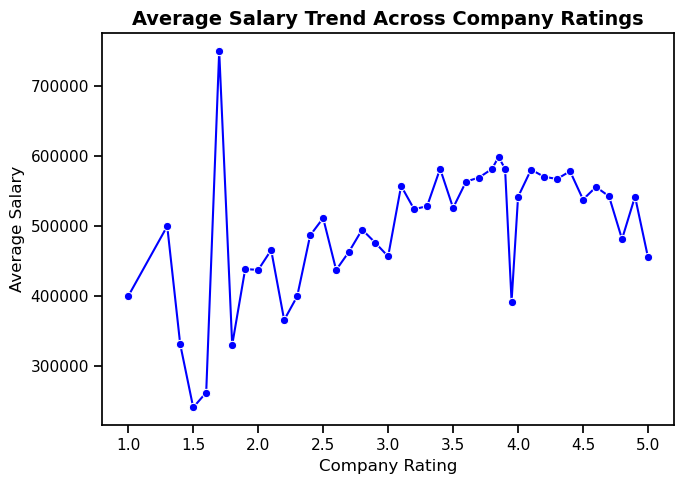

In [123]:
plt.figure(figsize = (7,5))
sns.lineplot(x = 'Rating', y = 'Salary', data = rating_salary, color = 'blue', marker = 'o')

plt.title("Average Salary Trend Across Company Ratings", fontsize = 14, fontweight = "bold")
plt.xlabel("Company Rating")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()

plt.show()

# Mini Dashboard

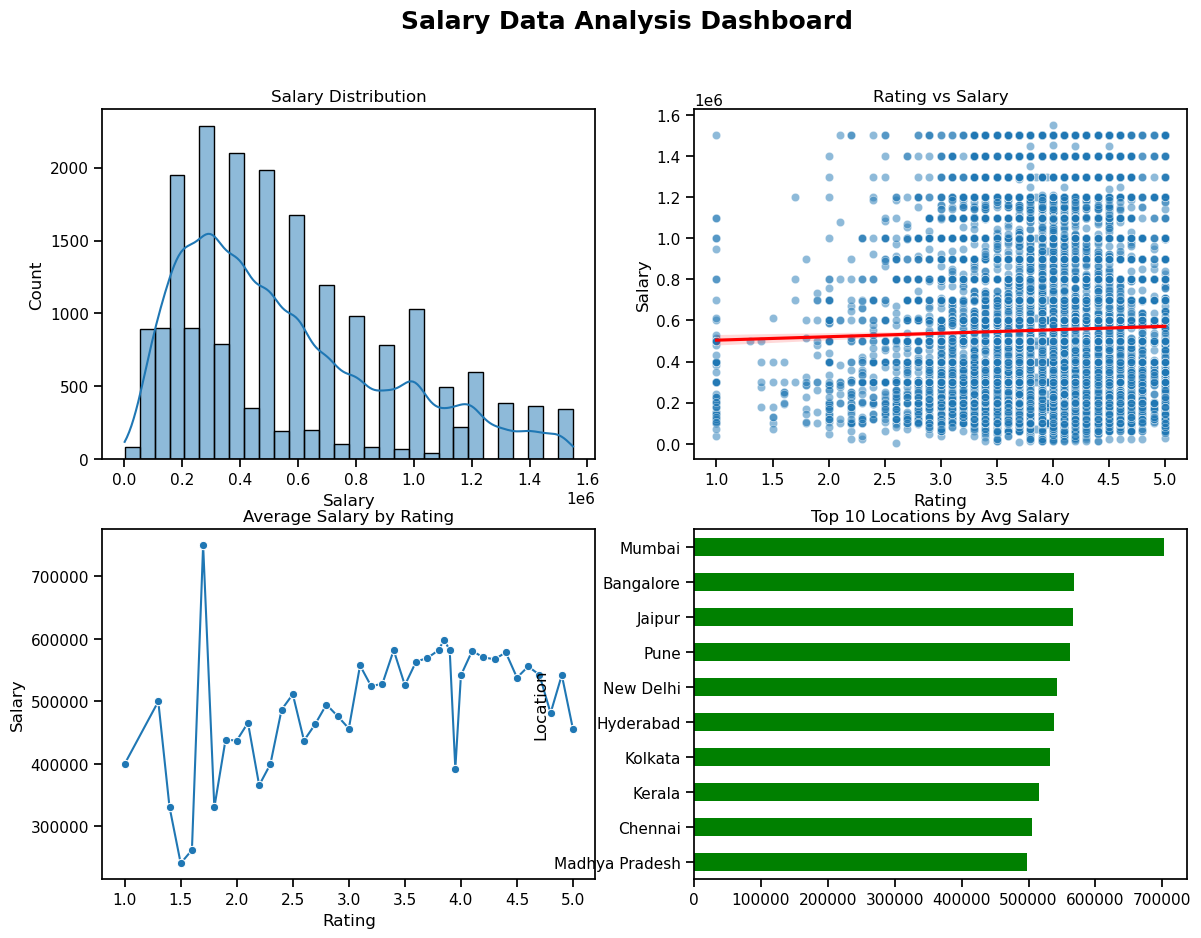

In [128]:
# Prepare data
rating_salary = data.groupby('Rating')['Salary'].mean().reset_index()
top_locations = data.groupby('Location')['Salary'].mean().sort_values(ascending = False)

# Create Dashboard Layout
plt.figure(figsize =(14,10))

#1. Salary Distribution
plt.subplot(2,2,1)
sns.histplot(data['Salary'], bins = 30, kde = True)
plt.title('Salary Distribution')


#2. Rating vs Salary
plt.subplot(2,2,2)
sns.scatterplot(x = "Rating", y = "Salary", data = data, alpha = 0.5)
sns.regplot(x = 'Rating', y = 'Salary', data = data, scatter = False, color = 'red')
plt.title("Rating vs Salary")

#3. Average Salary by Rating
plt.subplot(2,2,3)
sns.lineplot(x = 'Rating', y = 'Salary', data = rating_salary, marker = 'o')
plt.title("Average Salary by Rating")

#4. Top location
plt.subplot(2,2,4)
top_locations.sort_values().plot(kind='barh', color = 'green')
plt.title("Top 10 Locations by Avg Salary")

plt.suptitle("Salary Data Analysis Dashboard", fontsize = 18, fontweight = "bold")

plt.show()

# THANKYOU !